# Decision Trees

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset: Play Tennis](#1.-A-tiny-dataset:-Play-Tennis)
2. [The real dataset: Breast Cancer](#2.-The-real-dataset:-Breast-Cancer)
3. [Decision Tree at full scale](#3.-Decision-Tree-at-full-scale)
4. [Seeing the tree, on real features](#4.-Seeing-the-tree,-on-real-features)
5. [Overfitting: what happens without limits](#5.-Overfitting:-what-happens-without-limits)
6. [Regularization: max_depth and min_samples_split](#6.-Regularization:-max_depth-and-min_samples_split)
7. [Decision boundary, visually](#7.-Decision-boundary,-visually)
8. [Summary](#8.-Summary)

## 0. Introduction

Logistic Regression learns an equation. KNN votes by similarity. Decision Trees take a third approach: a sequence of yes/no questions, the way a person reasons through a decision.

This notebook starts with the classic lecture example, play tennis or not, decided from the weather, 10 rows, easy to trace by hand. Then it scales to Breast Cancer.

## 1. A tiny dataset: Play Tennis

Outlook, humidity, and wind, on 10 days.

In [1]:
import pandas as pd

tennis = pd.DataFrame({
    "Outlook":  ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain",
                 "Overcast", "Sunny", "Overcast", "Rain"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal",
                 "Normal", "Normal", "Normal", "High"],
    "Wind":     ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong",
                 "Strong", "Weak", "Weak", "Strong"],
    "Play":     ["No", "No", "Yes", "Yes", "Yes", "No",
                 "Yes", "Yes", "Yes", "No"],
})
tennis

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sunny,Normal,Weak,Yes
8,Overcast,Normal,Weak,Yes
9,Rain,High,Strong,No


`DecisionTreeClassifier` needs numbers, not strings. One-hot encode:

In [2]:
X_tennis = pd.get_dummies(tennis.drop(columns="Play"))
y_tennis = (tennis["Play"] == "Yes").astype(int)
X_tennis.head(3)

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,False,False,True,True,False,False,True
1,False,False,True,True,False,True,False
2,True,False,False,True,False,False,True


At each node the tree picks the question that minimizes the children's weighted-average Gini. `Entropy` is an alternative with the same goal; `scikit-learn` defaults to Gini. Fit and look:

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tennis_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tennis_tree.fit(X_tennis, y_tennis)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

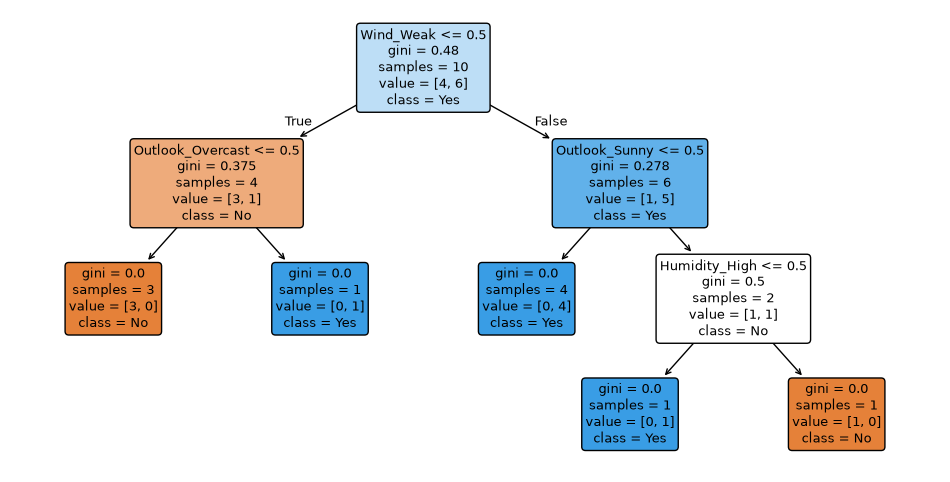

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(tennis_tree, feature_names=X_tennis.columns, class_names=["No", "Yes"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()

Same shape as lecture: `Overcast` is always "Yes", `Sunny` and `Rain` each need a second question, found automatically by minimizing Gini. On 10 rows the tree can memorize the data; the next sections show why that stops being fine at real scale.

## 2. The real dataset: Breast Cancer

Same setup as notebooks 2 and 3: load, split. No scaling this time, see why in section 3.

In [5]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3. Decision Tree at full scale

Same splitting rule as section 1, now on the real training set: is `worst radius` above some value, and if so, is `worst concave points` too?

In [7]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [8]:
from sklearn.metrics import accuracy_score

y_pred_tree = tree.predict(X_test)
print(f"Decision Tree (max_depth=4) test accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

Decision Tree (max_depth=4) test accuracy: 0.9386


`X_train`, not scaled. Trees compare a feature against a threshold, so units don't matter. The one model this week that never needs `StandardScaler`.

## 4. Seeing the tree, on real features

A shallow tree on the two strongest features, by correlation with the target:

In [9]:
features_2d = ["worst radius", "worst concave points"]
tree_2d = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_2d.fit(X_train[features_2d], y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

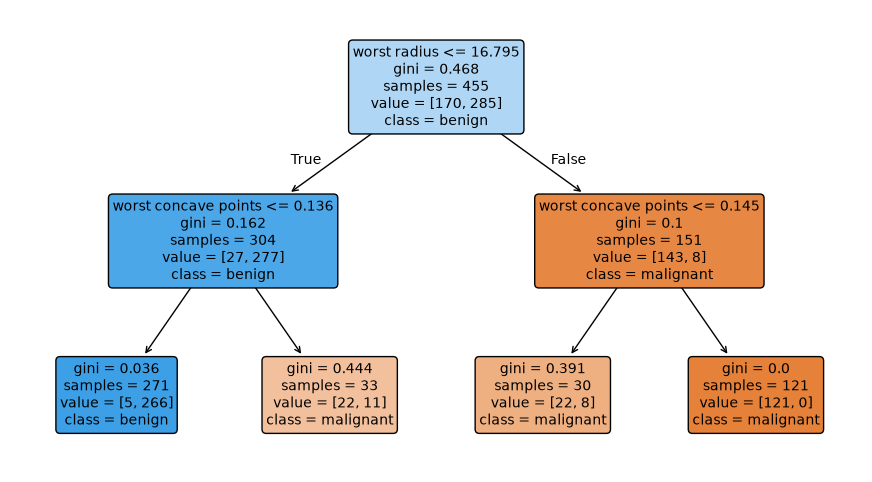

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_tree(tree_2d, feature_names=features_2d, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=10, ax=ax)
plt.show()

Root: `worst radius <= 16.795` splits 455 samples into mostly-benign vs. mostly-malignant, and each child repeats with `worst concave points`. Gini drops at each split, the same mechanism as the `Outlook` root split in section 1.

## 5. Overfitting: what happens without limits

Unlimited depth lets the tree memorize training data, the same failure mode as a degree-15 polynomial in week 3 or `k=1` in notebook 3's KNN.

In [11]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

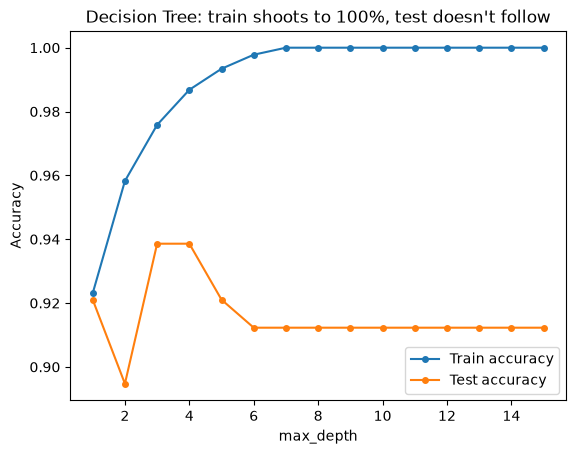

In [12]:
plt.plot(list(depths), train_acc, marker="o", markersize=4, label="Train accuracy")
plt.plot(list(depths), test_acc, marker="o", markersize=4, label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: train shoots to 100%, test doesn't follow")
plt.legend()
plt.show()

Train accuracy hits 1.0; test plateaus below it. The gap is overfitting, the same signature as week 3's learning curves.

## 6. Regularization: max_depth and min_samples_split

`max_depth` caps how deep the tree goes. `min_samples_split` blocks splitting nodes with too few samples.

In [13]:
for min_split in [2, 10, 30, 60]:
    m = DecisionTreeClassifier(min_samples_split=min_split, random_state=42).fit(X_train, y_train)
    print(f"min_samples_split={min_split:<3} test accuracy = {accuracy_score(y_test, m.predict(X_test)):.4f}")

min_samples_split=2   test accuracy = 0.9123
min_samples_split=10  test accuracy = 0.9035
min_samples_split=30  test accuracy = 0.9386
min_samples_split=60  test accuracy = 0.8947


Not strictly monotonic; a single split is a noisy measurement, and cross-validation applies here too. The takeaway is the range, not the exact winner.

## 7. Decision boundary, visually

Same synthetic 2D data used for Logistic Regression (notebook 2) and KNN (notebook 3).

In [14]:
import numpy as np
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

In [15]:
def plot_boundary(ax, model, X, y, title, proba_thresh=0.5):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[proba_thresh], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="white", linewidths=0.6, s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

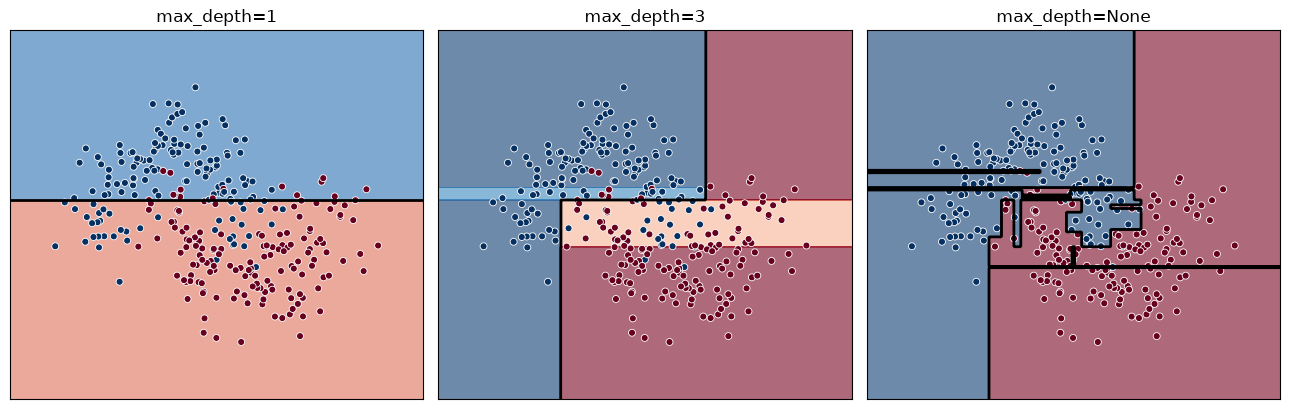

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, depth in zip(axes, [1, 3, None]):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_moons, y_moons)
    label = f"max_depth={depth}" if depth else "max_depth=None"
    plot_boundary(ax, m, X_moons, y_moons, label)
plt.tight_layout()
plt.show()

`max_depth=1` asks one question, barely better than guessing. Unlimited depth chases every point, jagged, the same as `k=1` in KNN. This instability motivates next week's Random Forest: many trees instead of one.

## 8. Summary

- Decision Trees decide with yes/no questions, each chosen to minimize Gini impurity, shown first on the 10-row Play Tennis dataset, which reproduced lecture's exact split structure.
- The same mechanism, at full scale, splits 455 real samples the same way, one feature threshold at a time.
- No scaling needed, the only model this week with that property.
- Unconstrained, a tree memorizes training data; `max_depth` and `min_samples_split` are the two main levers against it.
- The most visually inspectable of the three models, but also the least stable on its own.

Notebook 5 puts Logistic Regression, KNN, and Decision Trees side by side, and closes the week with exercises.